In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [2]:
def generate_mixture(n, mu1, mu2, sigma=1.0, w=0.6):
    n1 = int(n * w)
    n2 = n - n1

    x1 = np.random.normal(mu1, sigma, n1)
    x2 = np.random.normal(mu2, sigma, n2)

    return np.concatenate([x1, x2])

In [3]:
def simulate_pvalues(n, mu1, mu2, n_sim=100):
    pvals = []

    for _ in range(n_sim):
        data = generate_mixture(n, mu1, mu2)
        _, p = shapiro(data)
        pvals.append(p)

    return np.array(pvals)

In [4]:
def compute_statistics(pvals):
    mean_p = np.mean(pvals)
    ci_low = np.percentile(pvals, 2.5)
    ci_high = np.percentile(pvals, 97.5)

    return mean_p, ci_low, ci_high

In [5]:
def find_threshold(mu_values, all_pvals):
    for mu, pvals in zip(mu_values, all_pvals):
        if np.mean(pvals < 0.05) > 0.95:
            return mu
    return None

In [6]:
def plot_results(mu_values, mean_p, ci_low, ci_high, n, threshold):
    plt.figure()

    plt.plot(mu_values, mean_p)
    plt.fill_between(mu_values, ci_low, ci_high, alpha=0.3)

    plt.axhline(0.05)

    title = f"Размер выборки = {n}"
    if threshold is not None:
        title += f", пороговое значение Δμ ≈ {threshold}"
    else:
        title += ", порог не найден"

    plt.title(title)
    plt.xlabel("Δμ")
    plt.ylabel("Среднее")

    plt.show()

In [11]:
def run_experiment(sample_sizes, mu1=0):
    np.random.seed(42)

    mu_values = np.arange(0, 3.01, 0.25)
    results = {}

    for n in sample_sizes:
        mean_p_list = []
        ci_low_list = []
        ci_high_list = []
        all_pvals = []

        print(f"Размер выборки: {n}")

        for mu2 in mu_values:
            pvals = simulate_pvalues(n, mu1, mu2)

            mean_p, ci_low, ci_high = compute_statistics(pvals)

            mean_p_list.append(mean_p)
            ci_low_list.append(ci_low)
            ci_high_list.append(ci_high)
            all_pvals.append(pvals)

            print(f"Δμ = {mu2:.2f} | среднее p = {mean_p:.4f}")

        threshold = find_threshold(mu_values, all_pvals)
        results[n] = threshold

        plot_results(mu_values, mean_p_list, ci_low_list, ci_high_list, n, threshold)

    return results

Размер выборки: 50
Δμ = 0.00 | среднее p = 0.5327
Δμ = 0.25 | среднее p = 0.5346
Δμ = 0.50 | среднее p = 0.4795
Δμ = 0.75 | среднее p = 0.5074
Δμ = 1.00 | среднее p = 0.4546
Δμ = 1.25 | среднее p = 0.4824
Δμ = 1.50 | среднее p = 0.4473
Δμ = 1.75 | среднее p = 0.4443
Δμ = 2.00 | среднее p = 0.4314
Δμ = 2.25 | среднее p = 0.3822
Δμ = 2.50 | среднее p = 0.2345
Δμ = 2.75 | среднее p = 0.2761
Δμ = 3.00 | среднее p = 0.1358


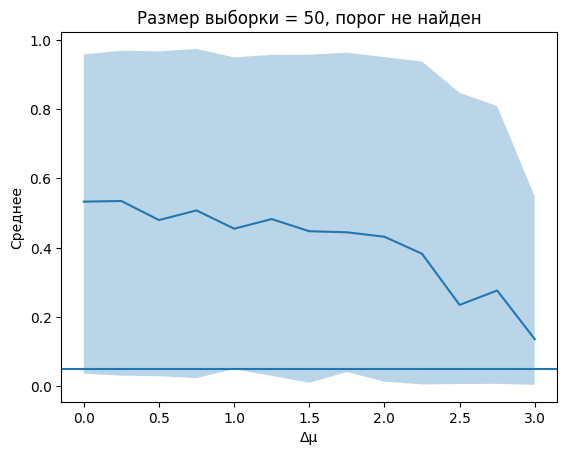

Размер выборки: 100
Δμ = 0.00 | среднее p = 0.4993
Δμ = 0.25 | среднее p = 0.5440
Δμ = 0.50 | среднее p = 0.5334
Δμ = 0.75 | среднее p = 0.5663
Δμ = 1.00 | среднее p = 0.5052
Δμ = 1.25 | среднее p = 0.4986
Δμ = 1.50 | среднее p = 0.4293
Δμ = 1.75 | среднее p = 0.4226
Δμ = 2.00 | среднее p = 0.2926
Δμ = 2.25 | среднее p = 0.2283
Δμ = 2.50 | среднее p = 0.1936
Δμ = 2.75 | среднее p = 0.0948
Δμ = 3.00 | среднее p = 0.0445


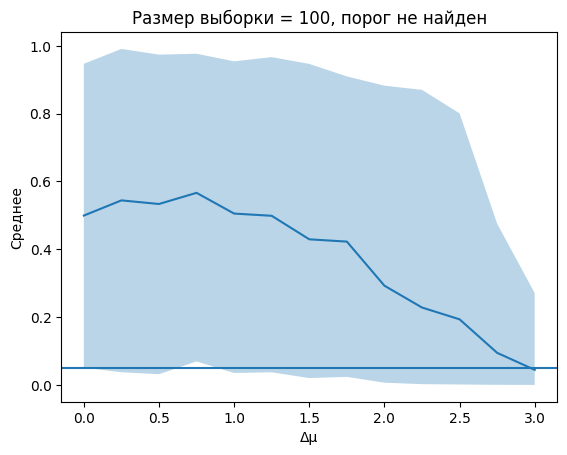

Размер выборки: 200
Δμ = 0.00 | среднее p = 0.4464
Δμ = 0.25 | среднее p = 0.4943
Δμ = 0.50 | среднее p = 0.4364
Δμ = 0.75 | среднее p = 0.4478
Δμ = 1.00 | среднее p = 0.4523
Δμ = 1.25 | среднее p = 0.4414
Δμ = 1.50 | среднее p = 0.4498
Δμ = 1.75 | среднее p = 0.3570
Δμ = 2.00 | среднее p = 0.2564
Δμ = 2.25 | среднее p = 0.1383
Δμ = 2.50 | среднее p = 0.0615
Δμ = 2.75 | среднее p = 0.0125
Δμ = 3.00 | среднее p = 0.0054


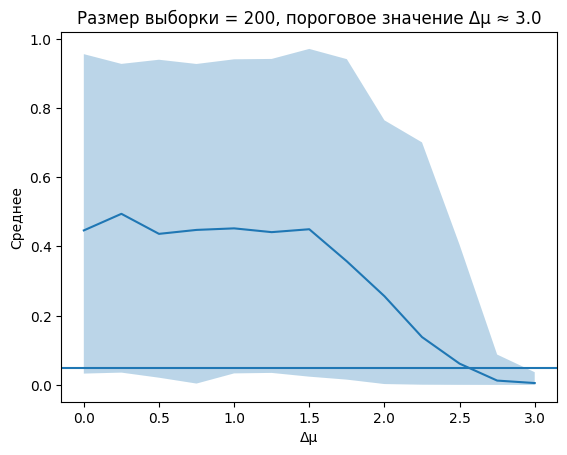

Размер выборки: 500
Δμ = 0.00 | среднее p = 0.5075
Δμ = 0.25 | среднее p = 0.4994
Δμ = 0.50 | среднее p = 0.5010
Δμ = 0.75 | среднее p = 0.4666
Δμ = 1.00 | среднее p = 0.4618
Δμ = 1.25 | среднее p = 0.4686
Δμ = 1.50 | среднее p = 0.3143
Δμ = 1.75 | среднее p = 0.1534
Δμ = 2.00 | среднее p = 0.0747
Δμ = 2.25 | среднее p = 0.0128
Δμ = 2.50 | среднее p = 0.0007
Δμ = 2.75 | среднее p = 0.0000
Δμ = 3.00 | среднее p = 0.0000


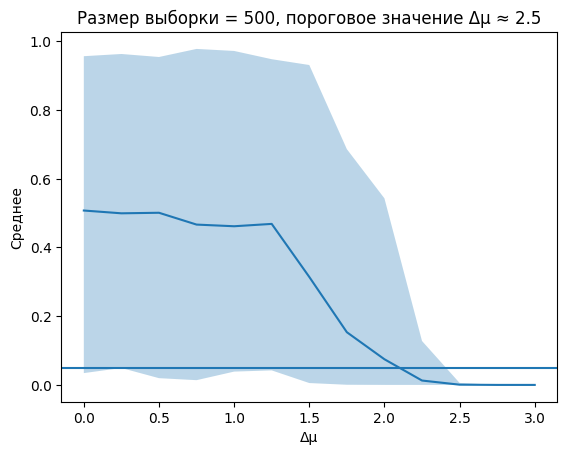

Пороговые значения
n = 50: Δμ ≈ None
n = 100: Δμ ≈ None
n = 200: Δμ ≈ 3.0
n = 500: Δμ ≈ 2.5


In [12]:
sample_sizes = [50, 100, 200, 500]

thresholds = run_experiment(sample_sizes)

print("Пороговые значения")
for n, t in thresholds.items():
    print(f"n = {n}: Δμ ≈ {t}")